# Training Playground
This notebook trains LightGBM **LambdaRank** models for 'Entry' and 'Exit' cue points.
It implements:
1. Strict **Track-Level Splitting** to prevent data leakage.
2. **Feature Selection** based on previous analysis (Tier 1-3).
3. **Training Visualization** (Learning Curves: NDCG@1 / NDCG@3).
4. **Ranking Evaluation Metrics** (Hit@k, MRR, Rank Distribution).


In [1]:
import sys
import pickle
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

sys.path.append('..')
from track import Track
from features import FeatureExtractor

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data & Extract Features
We use the finalized `FeatureExtractor` class to load data. 

In [2]:
data_dir = Path("../../data/processed")
pkl_files = list(data_dir.glob("*.pkl"))

print(f"Found {len(pkl_files)} processed tracks.")

all_features = []
all_labels = []

for pkl_path in pkl_files:
    try:
        with open(pkl_path, 'rb') as f:
            t = pickle.load(f)
            if t.num_bars > 0:
                # Features
                df_feats = FeatureExtractor.extract(t)
                
                # Labels
                df_labels = FeatureExtractor.extract_labels(t)
                
                all_features.append(df_feats)
                all_labels.append(df_labels)
    except Exception as e:
        print(f"Error loading {pkl_path.name}: {e}")

# Combine
X_full = pd.concat(all_features, ignore_index=True)
y_full = pd.concat(all_labels, ignore_index=True)

print(f"Total Rows: {len(X_full)}")
display(X_full.head())

Found 174 processed tracks.
Total Rows: 15686


,track_id,bar_index,bar_pos_norm,dist_to_section,phrase_pos,duration,is_4_bar,bar_mod_8,bar_mod_16,bar_mod_32,...,percussion_intensity,vocal_onset_likelihood,spectral_rolloff,melodic_complexity,phrase_boundary_strength,chroma_rel_0,chroma_rel_3,chroma_rel_7,chroma_rel_9,chroma_rel_11
0,Da Hype (Junior Jack Original Club Mix),0,0.000000,139.0,0,564.964717,1,1,1,1,...,0.151243,0.005363,9892.092507,5.0,4,0.561458,0.670468,0.709883,0.738923,0.729828
1,Da Hype (Junior Jack Original Club Mix),1,0.007246,138.0,1,564.964717,0,0,0,0,...,0.150609,0.005613,9898.532040,5.0,0,0.553019,0.672291,0.702327,0.737677,0.725393
2,Da Hype (Junior Jack Original Club Mix),2,0.014493,137.0,2,564.964717,0,0,0,0,...,0.159058,0.001271,9925.235829,5.0,0,0.553391,0.666988,0.697426,0.730974,0.729622
3,Da Hype (Junior Jack Original Club Mix),3,0.021739,136.0,3,564.964717,0,0,0,0,...,0.170890,0.000000,9909.265916,5.0,0,0.549810,0.665036,0.698714,0.725331,0.724910
4,Da Hype (Junior Jack Original Club Mix),4,0.028986,135.0,4,564.964717,1,0,0,0,...,0.171387,0.000000,9884.588512,5.0,1,0.552125,0.666748,0.689647,0.726555,0.721051


## 2. Define Features & Targets
We filter the DataFrame to keep only the features defined in `FeatureExtractor.FEATURES`. This matches our "Tier 1-3" selection from the previous analysis.

In [3]:
SELECTED_FEATURES = FeatureExtractor.FEATURES

# Check if any are missing
missing_feats = set(SELECTED_FEATURES) - set(X_full.columns)
if missing_feats:
    print(f"Warning: Missing features validation: {missing_feats}")
else:
    print(f"All {len(SELECTED_FEATURES)} selected features are present.")

X = X_full[SELECTED_FEATURES]
groups = X_full['track_id'] # For splitting
y_in = y_full['is_cue_in']
y_out = y_full['is_cue_out']

print(f"Feature Matrix Shape: {X.shape}")

All 41 selected features are present.
Feature Matrix Shape: (15686, 41)


## 3. Track-Level Train/Test Split
**Crucial Step:** We must split by `track_id`.

In [4]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y_in, groups=groups))

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]

# Targets for Entry
y_in_train = y_in.iloc[train_idx]
y_in_val = y_in.iloc[val_idx]

# Targets for Exit
y_out_train = y_out.iloc[train_idx]
y_out_val = y_out.iloc[val_idx]

print(f"Train Set: {len(X_train)} bars ({len(set(groups.iloc[train_idx]))} tracks)")
print(f"Test Set:  {len(X_val)} bars ({len(set(groups.iloc[val_idx]))} tracks)")

Train Set: 12624 bars (139 tracks)
Test Set:  3062 bars (35 tracks)


## 4. Cross-Validation Training

Starting 5-Fold Cross-Validation using BeatBotModel (LambdaRank)...
Training Entry Ranker...
Training Exit Ranker...


/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in 

Fold 1 | Entry Hit@3: 0.6765 | Exit Hit@3: 0.6765
Training Entry Ranker...
Training Exit Ranker...


/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in 

Fold 2 | Entry Hit@3: 0.6571 | Exit Hit@3: 0.7143
Training Entry Ranker...
Training Exit Ranker...


...

Fold 3 | Entry Hit@3: 0.6000 | Exit Hit@3: 0.6286
Training Entry Ranker...
Training Exit Ranker...


/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in 

Fold 4 | Entry Hit@3: 0.6571 | Exit Hit@3: 0.7429
Training Entry Ranker...
Training Exit Ranker...


/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Fold 5 | Entry Hit@3: 0.6286 | Exit Hit@3: 0.6571


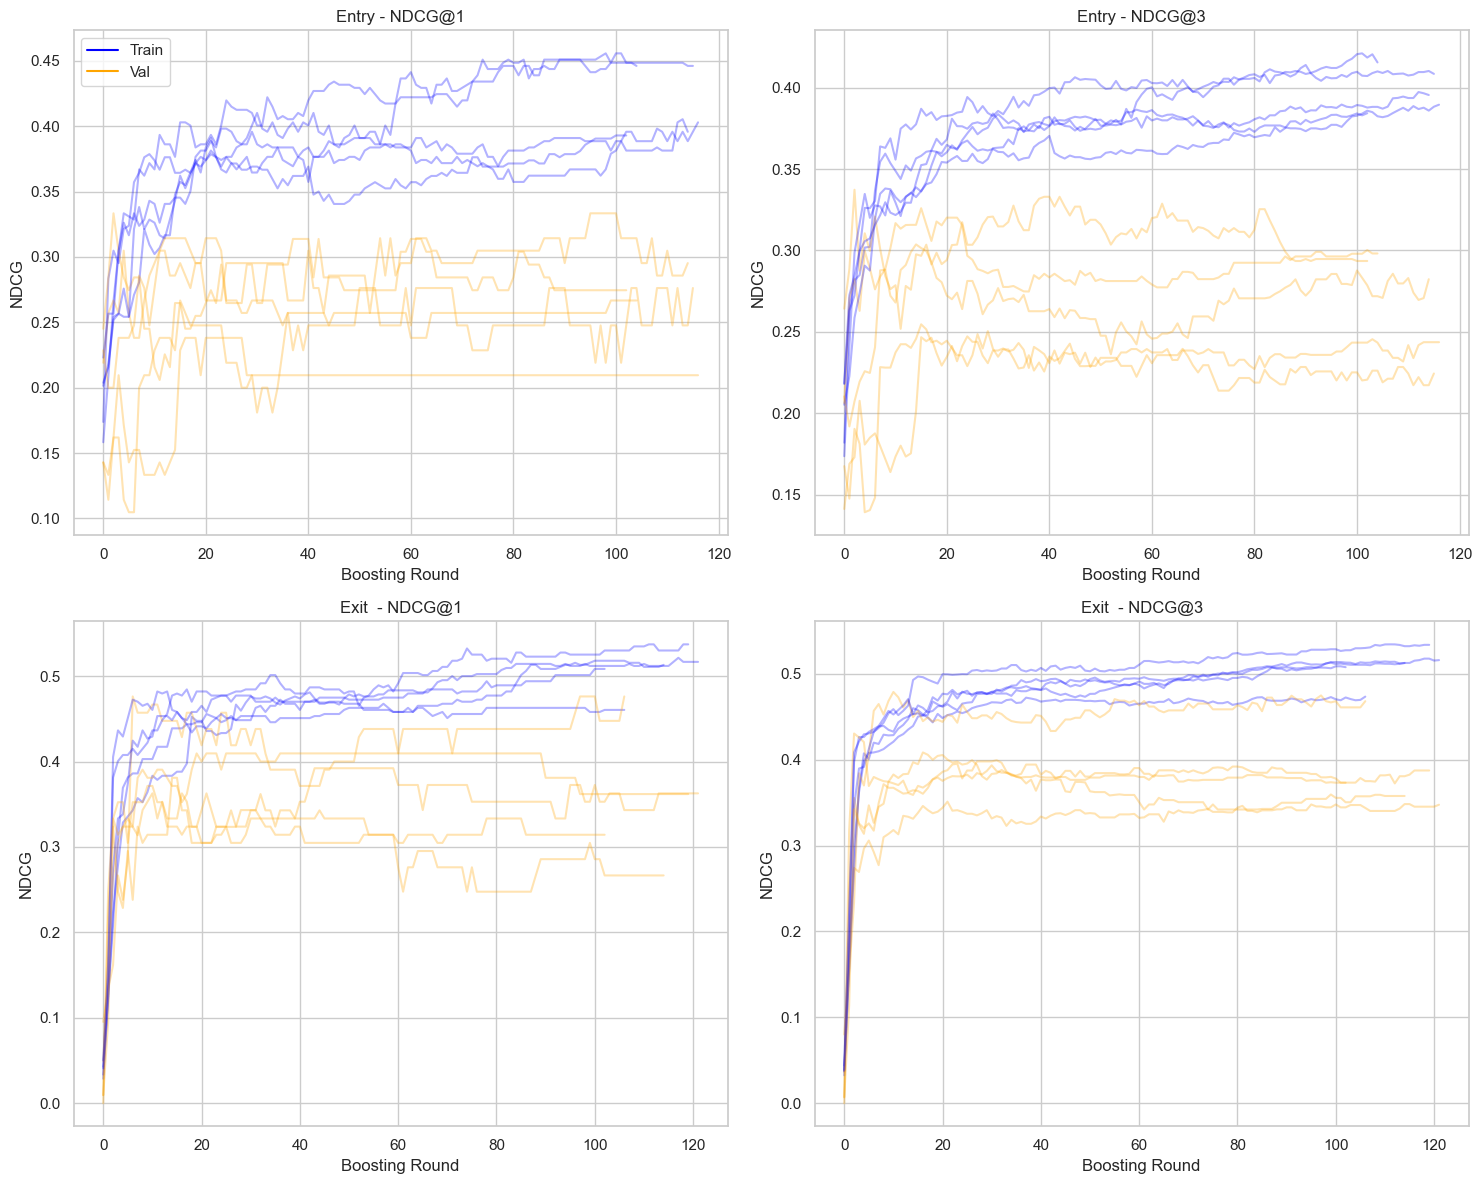


--- CV Results ---
Entry Hit@3: 0.6439  +/-  0.0267
Exit  Hit@3: 0.6839  +/-  0.0406


In [5]:
# 4. Cross-Validation Training
import importlib
import model.lightgbm
importlib.reload(model.lightgbm)
from model.lightgbm import BeatBotModel


def compute_hit_at_k(model, X_v, y_v, groups_v, k=3):
    """Hit@k: fraction of tracks where at least one true cue is in the top-k ranked bars."""
    scores = model.predict(X_v)
    hit_count, query_count = 0, 0
    start = 0
    for size in groups_v:
        end = start + size
        q_scores = scores[start:end]
        q_labels = y_v.values[start:end]
        if q_labels.sum() == 0:
            start = end
            continue
        top_k_idx = np.argsort(q_scores)[::-1][:k]
        if q_labels[top_k_idx].sum() > 0:
            hit_count += 1
        query_count += 1
        start = end
    return hit_count / query_count if query_count > 0 else 0.0


def train_cv(X, y_in, y_out, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)

    fold_hits_in  = []
    fold_hits_out = []

    best_model    = None
    best_avg_hit  = -1

    # 2x2: Entry/Exit  x  NDCG@1 / NDCG@3
    fig, ax = plt.subplots(2, 2, figsize=(15, 12))

    print(f"Starting {n_splits}-Fold Cross-Validation using BeatBotModel (LambdaRank)...")

    for i, (train_idx, val_idx) in enumerate(gkf.split(X, y_in, groups=groups)):
        # Data for this fold
        X_tr, X_v       = X.iloc[train_idx],    X.iloc[val_idx]
        y_in_tr, y_in_v  = y_in.iloc[train_idx],  y_in.iloc[val_idx]
        y_out_tr, y_out_v = y_out.iloc[train_idx], y_out.iloc[val_idx]

        # Group sizes required by LambdaRank
        groups_tr = BeatBotModel.compute_groups(groups.iloc[train_idx])
        groups_v  = BeatBotModel.compute_groups(groups.iloc[val_idx])

        bb_model = BeatBotModel()
        history  = bb_model.fit(
            X_tr, y_in_tr, y_out_tr,
            groups_train=groups_tr,
            X_val=X_v,
            y_in_val=y_in_v,
            y_out_val=y_out_v,
            groups_val=groups_v,
        )

        # --- Plot Entry curves (top row) ---
        if history.get('entry'):
            res    = history['entry']
            epochs = len(res['Train']['ndcg@1'])
            x_axis = range(epochs)
            ax[0, 0].plot(x_axis, res['Train']['ndcg@1'], alpha=0.3, color='blue')
            ax[0, 0].plot(x_axis, res['Val']['ndcg@1'],   alpha=0.3, color='orange')
            ax[0, 1].plot(x_axis, res['Train']['ndcg@3'], alpha=0.3, color='blue')
            ax[0, 1].plot(x_axis, res['Val']['ndcg@3'],   alpha=0.3, color='orange')

        # --- Plot Exit curves (bottom row) ---
        if history.get('exit'):
            res    = history['exit']
            epochs = len(res['Train']['ndcg@1'])
            x_axis = range(epochs)
            ax[1, 0].plot(x_axis, res['Train']['ndcg@1'], alpha=0.3, color='blue')
            ax[1, 0].plot(x_axis, res['Val']['ndcg@1'],   alpha=0.3, color='orange')
            ax[1, 1].plot(x_axis, res['Train']['ndcg@3'], alpha=0.3, color='blue')
            ax[1, 1].plot(x_axis, res['Val']['ndcg@3'],   alpha=0.3, color='orange')

        # Per-fold evaluation via Hit@3
        hit_in  = compute_hit_at_k(bb_model.entry_model, X_v, y_in_v,  groups_v, k=3)
        hit_out = compute_hit_at_k(bb_model.exit_model,  X_v, y_out_v, groups_v, k=3)
        fold_hits_in.append(hit_in)
        fold_hits_out.append(hit_out)

        print(f"Fold {i+1} | Entry Hit@3: {hit_in:.4f} | Exit Hit@3: {hit_out:.4f}")

        avg_hit = (hit_in + hit_out) / 2
        if avg_hit > best_avg_hit:
            best_avg_hit = avg_hit
            best_model   = bb_model

    # Finalize plots
    ax[0, 0].set_title('Entry - NDCG@1')
    ax[0, 1].set_title('Entry - NDCG@3')
    ax[1, 0].set_title('Exit  - NDCG@1')
    ax[1, 1].set_title('Exit  - NDCG@3')

    ax[0, 0].plot([], [], color='blue',   label='Train')
    ax[0, 0].plot([], [], color='orange', label='Val')
    ax[0, 0].legend()
    for a in ax.flat:
        a.set_xlabel('Boosting Round')
        a.set_ylabel('NDCG')

    plt.tight_layout()
    plt.show()

    print(f"\n--- CV Results ---")
    print(f"Entry Hit@3: {np.mean(fold_hits_in):.4f}  +/-  {np.std(fold_hits_in):.4f}")
    print(f"Exit  Hit@3: {np.mean(fold_hits_out):.4f}  +/-  {np.std(fold_hits_out):.4f}")

    return best_model


final_model = train_cv(X, y_in, y_out, groups)


## 5. Evaluation on Hold-Out Set
Ranking metrics: **Hit@k**, **MRR**, and a histogram showing where the true cue point lands in the ranked list.


--- Ranking Evaluation: Entry Cue ---
  Hit@1: 0.5429
  Hit@3: 0.6286
  Hit@5: 0.6857
  MRR:   0.4905
  % tracks where true cue is in top-3: 54.3%


/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in 

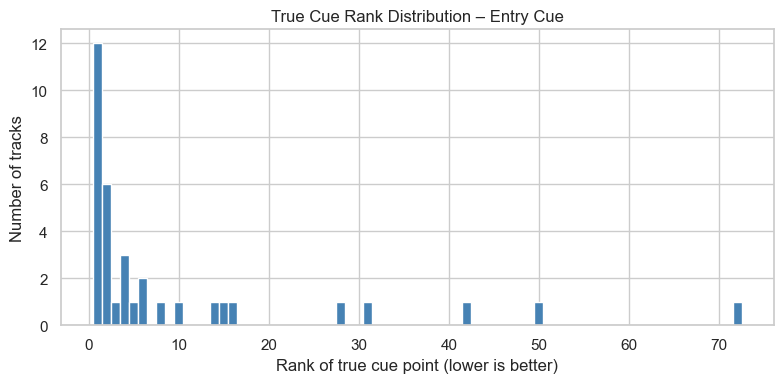

--- Ranking Evaluation: Exit Cue ---
  Hit@1: 0.5429
  Hit@3: 0.7143
  Hit@5: 0.8286
  MRR:   0.4250
  % tracks where true cue is in top-3: 65.7%


/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in 

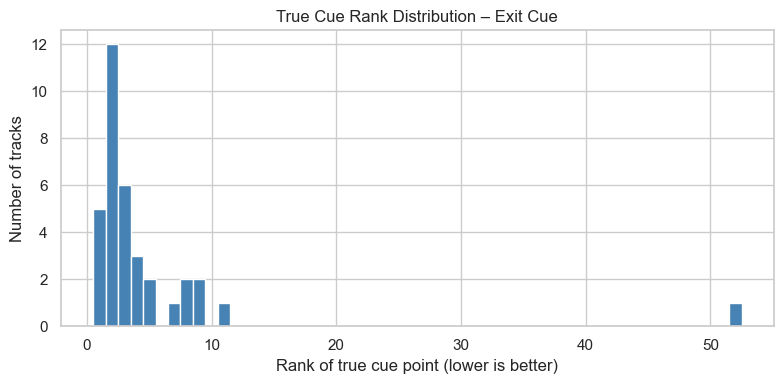

In [6]:
def compute_mrr(model, X_v, y_v, groups_v):
    """Mean Reciprocal Rank: average of 1/rank of the first true cue per track."""
    scores = model.predict(X_v)
    mrr_sum, count = 0.0, 0
    start = 0
    for size in groups_v:
        end     = start + size
        q_s     = scores[start:end]
        q_l     = y_v.values[start:end]
        if q_l.sum() == 0:
            start = end
            continue
        ranked = np.argsort(q_s)[::-1]
        for rank, idx in enumerate(ranked, 1):
            if q_l[idx] == 1:
                mrr_sum += 1.0 / rank
                break
        count += 1
        start  = end
    return mrr_sum / count if count > 0 else 0.0

def get_true_cue_ranks(model, X_v, y_v, groups_v):
    """Returns the rank (1-based) of the first true cue for each track."""
    scores = model.predict(X_v)
    ranks  = []
    start  = 0
    for size in groups_v:
        end    = start + size
        q_s    = scores[start:end]
        q_l    = y_v.values[start:end]
        if q_l.sum() == 0:
            start = end
            continue
        ranked = np.argsort(q_s)[::-1]
        for rank, idx in enumerate(ranked, 1):
            if q_l[idx] == 1:
                ranks.append(rank)
                break
        start = end
    return ranks

def evaluate_ranking(model, X_v, y_v, groups_v, title="Entry"):
    print(f"--- Ranking Evaluation: {title} ---")
    for k in [1, 3, 5]:
        hit = compute_hit_at_k(model, X_v, y_v, groups_v, k=k)
        print(f"  Hit@{k}: {hit:.4f}")

    mrr = compute_mrr(model, X_v, y_v, groups_v)
    print(f"  MRR:   {mrr:.4f}")

    ranks = get_true_cue_ranks(model, X_v, y_v, groups_v)
    if ranks:
        pct_top3 = np.mean(np.array(ranks) <= 3) * 100
        print(f"  % tracks where true cue is in top-3: {pct_top3:.1f}%")
        plt.figure(figsize=(8, 4))
        plt.hist(ranks, bins=range(1, max(ranks) + 2), color='steelblue', edgecolor='white', align='left')
        plt.xlabel('Rank of true cue point (lower is better)')
        plt.ylabel('Number of tracks')
        plt.title(f'True Cue Rank Distribution – {title}')
        plt.tight_layout()
        plt.show()


# Compute hold-out group sizes
groups_val_arr = BeatBotModel.compute_groups(groups.iloc[val_idx])

evaluate_ranking(final_model.entry_model, X_val, y_in_val,  groups_val_arr, "Entry Cue")
evaluate_ranking(final_model.exit_model,  X_val, y_out_val, groups_val_arr, "Exit Cue")


## 6. Feature Importance of Final Rankers
Double check that `bar_pos_norm` and `energy_diff` are still driving the decisions.

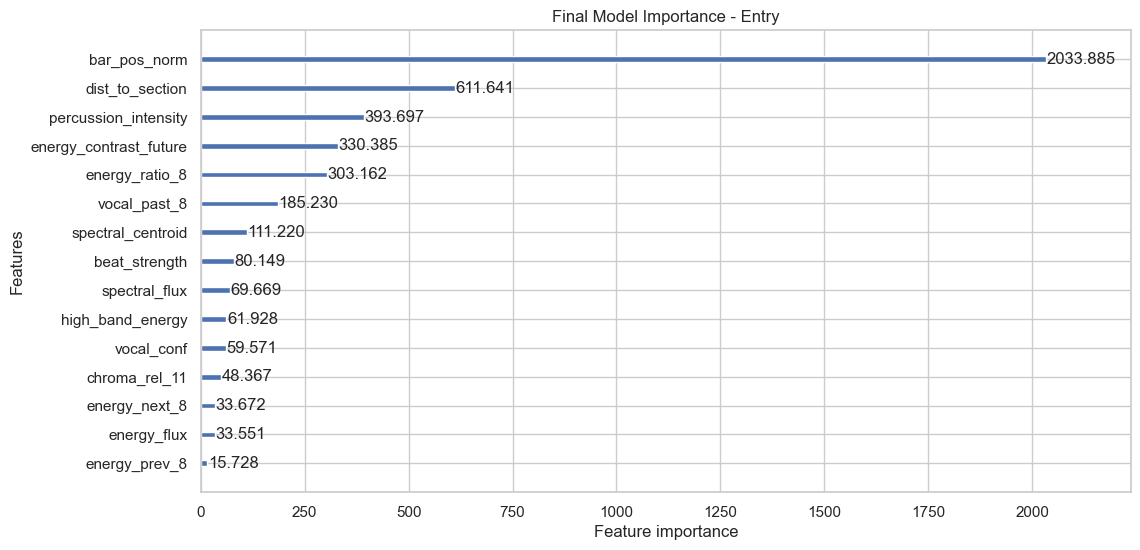

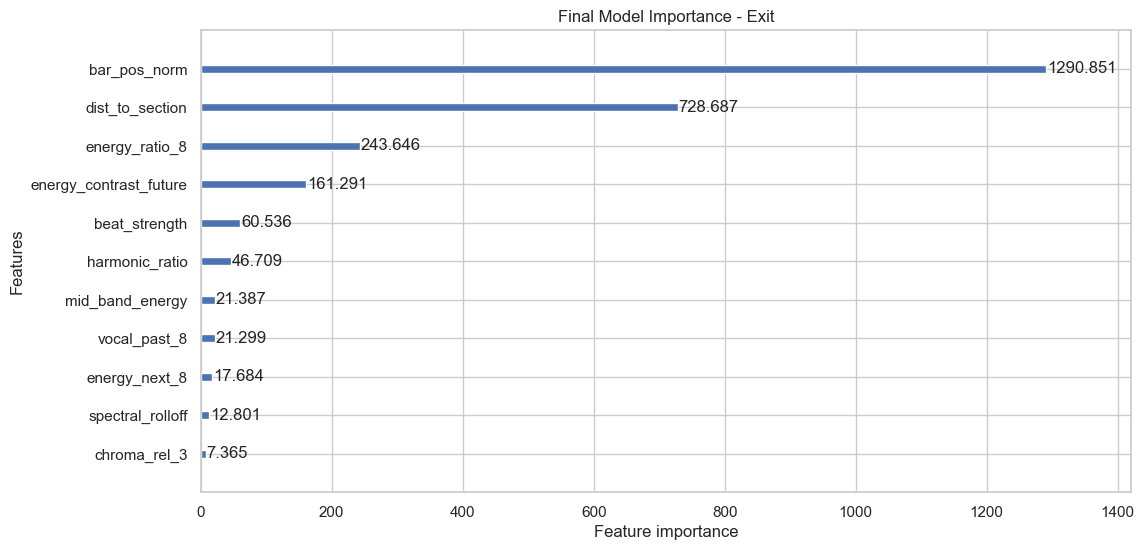

In [7]:
# 7. Feature Importance
lgb.plot_importance(final_model.entry_model, importance_type='gain', max_num_features=15, title='Final Model Importance - Entry')
plt.show()

lgb.plot_importance(final_model.exit_model, importance_type='gain', max_num_features=15, title='Final Model Importance - Exit')
plt.show()

## 7. Try predictions on Actual Data Using Model

In [15]:
for i in range(len(pkl_files)):
    print(f"{i}: {pkl_files[i].name}")

0: Da Hype (Junior Jack Original Club Mix).pkl
1: Kariya~Let Me Love You For Tonight [Original House Club Version].pkl
2: RALPHI ROSARIO - YOU USED TO HOLD ME 12 INCH.pkl
3: &ME, Adam Port & Rampa - Discoteca (feat. Sofie).pkl
4: RÜFÜS DU SOL - Innerbloom.pkl
5: RÜFÜS DU SOL - Make It Happen.pkl
6: Bog & GHEIST - Venere (Fideles Remix).pkl
7: Peggy Gou - Starry Night.pkl
8: Shouse - Won't Forget You (Edit).pkl
9: WizTheMc & bees & honey - Show Me Love.pkl
10: Drega & Simmy - Ezizweni.pkl
11: E-N - The Horn Ride (Deep Dish On Some Good Crack).pkl
12: RÜFÜS DU SOL - Rendezvous.pkl
13: CamelPhat & ARTBAT - For a Feeling (feat. RHODES).pkl
14: Coyu - Unexpected Souvenir (Original Mix).pkl
15: Quince - Sub 01.pkl
16: Shouse - Love Tonight (Edit).pkl
17: Roy Davis Jr ft Peven Everett - Gabriel (Live Garage Version).pkl
18: Drake - Overdrive.pkl
19: Fred again.. & Delilah Montagu - Delilah (pull me out of this).pkl
20: Kerri Chandler-Track One (Atmosphere EP).pkl
21: Fred again.. - Angie (I’v

Testing Ranker Inference on: Shouse - Love Tonight (Edit).mp3
Duration: 2:51 | Bars: 41


/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in 


--- Ranker Prediction Result (Top 3) ---
Entry:
  #1: Bar 10   @ 0:39 (Score: 0.0438)
  #2: Bar 27   @ 1:45 (Score: -0.0617)
Exit :
  #1: Bar 40   @ 2:36 (Score: 0.0247)
  #2: Bar 22   @ 1:26 (Score: 0.0090)
  #3: Bar 6    @ 0:24 (Score: -0.0176)

Ground Truth:
  In:  Bars [10] -> ['0:39']
  Out: Bars [40, 40] -> ['2:36', '2:36']


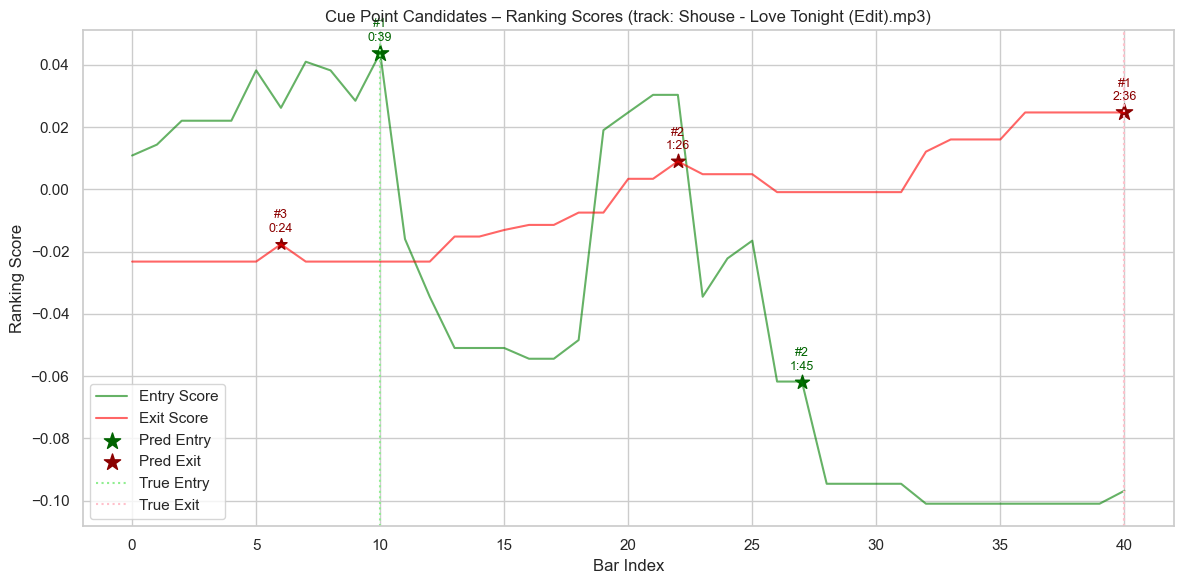

In [17]:
import importlib
import model.lightgbm
importlib.reload(model.lightgbm)
from model.lightgbm import BeatBotModel

# Helper for human-readable time
def to_min_sec(seconds):
    if seconds < 0: return "Unknown"
    m = int(seconds // 60)
    s = int(seconds % 60)
    return f"{m}:{s:02d}"

# Pick a sample track
if not pkl_files:
    print("No pkl files found. Make sure you ran the previous cells.")
else:
    test_pkl = pkl_files[16]
    with open(test_pkl, 'rb') as f:
        sample_track = pickle.load(f)

    track_name = sample_track.audio_path.name if sample_track.audio_path else sample_track.track_id
    print(f"Testing Ranker Inference on: {track_name}")
    print(f"Duration: {to_min_sec(sample_track.duration)} | Bars: {len(sample_track.bars)}")

    smart_model = BeatBotModel()
    if 'final_model' in globals():
        smart_model.entry_model = final_model.entry_model
        smart_model.exit_model  = final_model.exit_model
    else:
        print("Warning: final_model not found. Run the Cross-Validation cell first.")

    # Rank-based cue point selection (no threshold needed)
    cues = smart_model.predict_cue_points(sample_track, top_k=3, min_dist_bars=16)

    print("\n--- Ranker Prediction Result (Top 3) ---")

    def print_cues(label, cue_list):
        print(f"{label}:")
        for i, c in enumerate(cue_list):
            bar_idx = c['bar_index']
            ts      = sample_track.bars[bar_idx] if bar_idx < len(sample_track.bars) else -1.0
            score   = c['score']
            print(f"  #{i+1}: Bar {bar_idx:<4} @ {to_min_sec(ts)} (Score: {score:.4f})")

    print_cues("Entry", cues['cue_in'])
    print_cues("Exit ", cues['cue_out'])

    # Ground truth
    true_in_bars = []
    if len(sample_track.cue_in) > 0:
        idxs = np.searchsorted(sample_track.bars, sample_track.cue_in)
        true_in_bars = np.clip(idxs, 0, sample_track.num_bars - 1).tolist()

    true_out_bars = []
    if len(sample_track.cue_out) > 0:
        idxs = np.searchsorted(sample_track.bars, sample_track.cue_out)
        true_out_bars = np.clip(idxs, 0, sample_track.num_bars - 1).tolist()

    print(f"\nGround Truth:")
    print(f"  In:  Bars {true_in_bars} -> {[to_min_sec(sample_track.bars[b]) for b in true_in_bars]}")
    print(f"  Out: Bars {true_out_bars} -> {[to_min_sec(sample_track.bars[b]) for b in true_out_bars]}")

    # Visualise raw scores
    df_scores  = smart_model.predict_track(sample_track)
    max_score  = max(df_scores['score_in'].max(), df_scores['score_out'].max())
    min_score  = min(df_scores['score_in'].min(), df_scores['score_out'].min())
    score_range = max_score - min_score if max_score != min_score else 1.0

    plt.figure(figsize=(12, 6))
    plt.plot(df_scores['bar_index'], df_scores['score_in'],  label='Entry Score', color='green', alpha=0.6)
    plt.plot(df_scores['bar_index'], df_scores['score_out'], label='Exit Score',  color='red',   alpha=0.6)

    # Predicted candidates
    for i, c in enumerate(cues['cue_in']):
        ts = sample_track.bars[c['bar_index']]
        plt.scatter([c['bar_index']], [c['score']], color='darkgreen', s=150 - i*40, marker='*',
                    label='Pred Entry' if i == 0 else "")
        plt.text(c['bar_index'], c['score'] + score_range * 0.02,
                 f"#{i+1}\n{to_min_sec(ts)}", color='darkgreen', ha='center', va='bottom', fontsize=9)

    for i, c in enumerate(cues['cue_out']):
        ts = sample_track.bars[c['bar_index']]
        plt.scatter([c['bar_index']], [c['score']], color='darkred', s=150 - i*40, marker='*',
                    label='Pred Exit' if i == 0 else "")
        plt.text(c['bar_index'], c['score'] + score_range * 0.02,
                 f"#{i+1}\n{to_min_sec(ts)}", color='darkred', ha='center', va='bottom', fontsize=9)

    # Ground truth markers
    for t_in in true_in_bars:
        plt.axvline(x=t_in,  color='lightgreen', linestyle=':', label='True Entry')
    for t_out in true_out_bars:
        plt.axvline(x=t_out, color='pink',       linestyle=':', label='True Exit')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())

    plt.xlabel("Bar Index")
    plt.ylabel("Ranking Score")
    plt.title(f"Cue Point Candidates – Ranking Scores (track: {track_name})")
    plt.tight_layout()
    plt.show()


## 8. Save models and Metrics

In [18]:
import json
import os
from datetime import datetime

def save_artifacts(final_model, X_v, y_in_v, y_out_v, groups_v_arr, base_dir="../../data/models"):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir   = os.path.join(base_dir, f"run_{timestamp}")
    os.makedirs(run_dir, exist_ok=True)

    def get_metrics(model, X, y, groups):
        return {
            "hit@1":  compute_hit_at_k(model, X, y, groups, k=1),
            "hit@3":  compute_hit_at_k(model, X, y, groups, k=3),
            "hit@5":  compute_hit_at_k(model, X, y, groups, k=5),
            "mrr":    compute_mrr(model, X, y, groups),
        }

    metrics_in  = get_metrics(final_model.entry_model, X_v, y_in_v,  groups_v_arr)
    metrics_out = get_metrics(final_model.exit_model,  X_v, y_out_v, groups_v_arr)

    evaluation_data = {
        "timestamp":   timestamp,
        "entry_model": metrics_in,
        "exit_model":  metrics_out,
        "features":    SELECTED_FEATURES,
    }

    json_path = os.path.join(run_dir, "evaluation.json")
    with open(json_path, "w") as f:
        json.dump(evaluation_data, f, indent=4)
    print(f"Metrics saved to: {json_path}")

    model_path = os.path.join(run_dir, "beatbot_model.pkl")
    final_model.models_dir = Path(run_dir)
    final_model.save("beatbot_model.pkl")

    return run_dir

# Uncomment to save:
last_run_dir = save_artifacts(final_model, X_val, y_in_val, y_out_val, groups_val_arr)
print(f"Run completed. Artifacts in {last_run_dir}")


/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/romanos/Documents/BeatBot/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in 

Metrics saved to: ../../data/models/run_20260218_231046/evaluation.json
Model saved to ../../data/models/run_20260218_231046/beatbot_model.pkl
Run completed. Artifacts in ../../data/models/run_20260218_231046
